# ODC-STAC

This library compiles xarray datacubes from lists of STAC items. It plays nicely with pystac_client, the standard python client for querying STAC catalogs.

Let's get into it.

In [1]:
import pickle
import os
import pystac_client
import odc.stac
from dask.distributed import Client, WorkerPlugin
import boto3

In [2]:
with open("../params.pkl", "rb") as fp:
    p = pickle.load(fp)
bounds = p["box_3035"].bounds

In [3]:
URL = "https://stac.dataspace.copernicus.eu/v1"
cat = pystac_client.Client.open(URL)
cat.add_conforms_to("ITEM_SEARCH")

In [4]:
params = {
    "limit": 100,
    "collections": "sentinel-2-l2a",
    "datetime": f"{p['start'].strftime('%Y-%m-%d')}/{p['end'].strftime('%Y-%m-%d')}",
    "bbox": p["box_4326"].bounds,
    "query": {"eo:cloud_cover": {"lte": 80}},
    "sortby": "properties.eo:cloud_cover",
    "fields": {"exclude": ["geometry"]},
}

In [5]:
%%time
stac_items = list(cat.search(**params).item_collection())

CPU times: total: 78.1 ms
Wall time: 937 ms


We need to configure rasterio to provide the access credentials for the creodias S3. The credentials are manually entered in `~/.aws/credentials` and are injected here using boto3.

In [6]:
session = boto3.Session(profile_name="eodata")
credentials = session.get_credentials()
frozen = credentials.get_frozen_credentials()

os.environ.update(
    {
        "AWS_ACCESS_KEY_ID": frozen.access_key,
        "AWS_SECRET_ACCESS_KEY": frozen.secret_key,
        "AWS_S3_ENDPOINT": "eodata.dataspace.copernicus.eu",  # no scheme
        "AWS_VIRTUAL_HOSTING": "FALSE",
        "AWS_HTTPS": "YES",
        "AWS_DEFAULT_REGION": "default",
        # trying to get 429s under control
        "GDAL_HTTP_MAX_RETRY": "5",
        "GDAL_HTTP_RETRY_DELAY": "1",
        "GDAL_HTTP_TCP_KEEPALIVE": "YES",
        "GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR",
        "CPL_VSIL_CURL_ALLOWED_EXTENSIONS": ".jp2,.tif,.tiff",
        "VSI_CACHE": "TRUE",
        "VSI_CACHE_SIZE": "67108864",
    }
)

Without specifying the `chunk` parameter in the `odc.stac.load()` call, the dataset is loaded eagerly in a single thread. We expect this to be quite slow because unless odc-stac implemented cooperative single-threaded async the process will mainly be idle, waiting for requests to complete.

In [7]:
%%time
dataset = odc.stac.load(
    stac_items,
    bands=["B08_10m", "B11_20m", "SCL_20m"],
    x=(bounds[0], bounds[2]),
    y=(bounds[1], bounds[3]),
    crs="EPSG:3035",
    groupby="solar_day",
    resolution=10,
)

CPU times: total: 34.1 s
Wall time: 19min 16s


And indeed it is anything but fast.

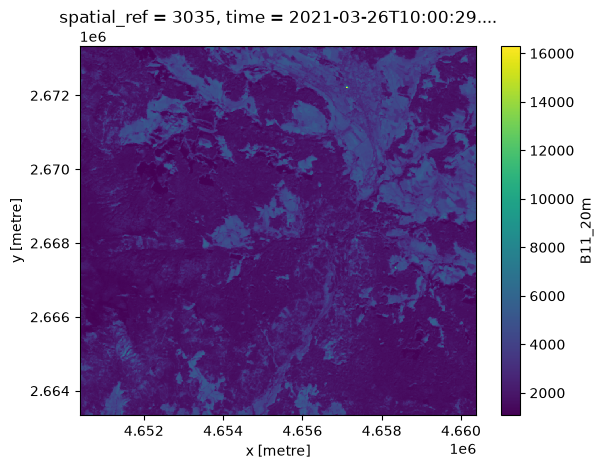

In [9]:
dataset.B11_20m.isel(time=22).plot();

This takes forever, so let's try and speed it up with dask. In theory if the package is set up well, we should be able to get away only with a higher number of threads, since the datacube generation should be heavily I/O bound.

In [7]:
dataset = odc.stac.load(
    stac_items,
    bands=["B08_10m", "B11_20m", "SCL_20m"],
    x=(bounds[0], bounds[2]),
    y=(bounds[1], bounds[3]),
    crs="EPSG:3035",
    groupby="solar_day",
    resolution=10,
    chunks={},  # this converts to a lazy dask dataframe
)

With this it builds a lazy dataframe, so no data was fetched yet. Only the call graph on how to instantiate the data has been built. The next call with `.compute()` actually fetches the data.

We will use 4 threads, since per the docs S3 allows 4 concurrent connections and 2000 requests per minute. And indeed, in tests if we increase the number of threads to 8, we were running into dropped requests due to rate limiting.

In [8]:
%%time
computed = dataset.compute(scheduler="threads", num_workers=8)

c:\Users\Jonas.Viehweger\Documents\Projects\2026\s2-time-series-access\odc-stac-nb\.venv\Lib\site-packages\rasterio\warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


CPU times: total: 24.5 s
Wall time: 7min 28s


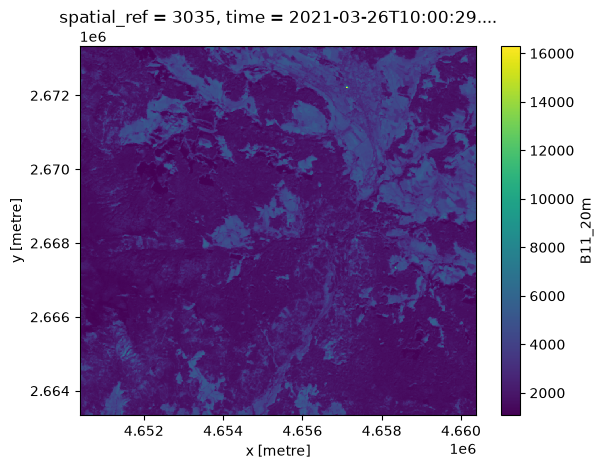

In [9]:
computed.B11_20m.isel(time=22).plot();

This is quite a bit faster.

We can also run on multiple cores, truly multi-processing. This should alleviate any performance bottlenecks which could happen during reprojection. However since all of the dask workers are their own processes, we need to inject the appropriate Environment variables so they also have access to the S3 credentials. It also brings more scheduling overhead, wrangling the different workers, so for small AOIs there likely won't be a lot of benefit.

In [15]:
class CDSEGdalEnv(WorkerPlugin):
    def __init__(self, env):
        self.env = env

    def setup(self, worker):
        os.environ.update(self.env)


client = Client(n_workers=8, threads_per_worker=1)  # 4 workers, 8 threads each
client.register_plugin(
    CDSEGdalEnv(
        {
            "AWS_S3_ENDPOINT": "eodata.dataspace.copernicus.eu",
            "AWS_VIRTUAL_HOSTING": "FALSE",
            "AWS_HTTPS": "YES",
            "AWS_DEFAULT_REGION": "default",
            "AWS_ACCESS_KEY_ID": frozen.access_key,
            "AWS_SECRET_ACCESS_KEY": frozen.secret_key,
        }
    )
)

{'tcp://127.0.0.1:62739': {'status': 'OK'},
 'tcp://127.0.0.1:62742': {'status': 'OK'},
 'tcp://127.0.0.1:62744': {'status': 'OK'},
 'tcp://127.0.0.1:62748': {'status': 'OK'},
 'tcp://127.0.0.1:62749': {'status': 'OK'},
 'tcp://127.0.0.1:62754': {'status': 'OK'},
 'tcp://127.0.0.1:62755': {'status': 'OK'},
 'tcp://127.0.0.1:62760': {'status': 'OK'}}

In [16]:
dataset = odc.stac.load(
    stac_items,
    bands=["B08_10m", "B11_20m", "SCL_20m"],
    x=(bounds[0], bounds[2]),
    y=(bounds[1], bounds[3]),
    crs="EPSG:3035",
    groupby="solar_day",
    resolution=10,
    chunks={},
)

In [17]:
%%time
dataset = dataset.compute()

CPU times: total: 3 s
Wall time: 8min 49s


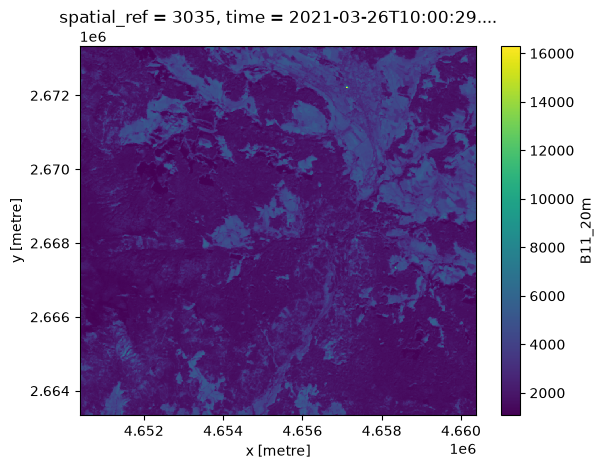

In [51]:
dataset.B11_20m.isel(time=22).plot();

This actually takes longer. So it's likely best to stick with single-core multithreaded when using odc-stac.